<a href="https://colab.research.google.com/github/janepium/deteccion-anomalias-rt-iot/blob/main/notebooks/02_analisis_trafico_volumen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Análisis exploratorio de datos enfocado en variables de tráfico y volumen de red**

En esta sección se realiza un análisis exploratorio de datos enfocado en variables relacionadas con el tráfico y volumen de red del dataset RT-IoT2022. El objetivo es estudiar el comportamiento de variables como la duración del flujo, la cantidad de paquetes enviados y recibidos, la tasa de paquetes por segundo, la relación entre tráfico de descarga y subida, y la cantidad de bytes de carga útil transmitidos por segundo.

Estas variables permiten caracterizar la comunicación generada por dispositivos IoT y comparar su comportamiento frente a los diferentes valores de la variable Attack_type. Este análisis es importante porque ciertos ataques o comportamientos anómalos pueden reflejarse en cambios en la duración de los flujos, el volumen de paquetes, la velocidad de transmisión o la relación entre tráfico entrante y saliente.

# 1. Configuración inicial

Para comenzar, se importan las librerías necesarias para el análisis de datos y la visualización de gráficos.

In [ ]:
!pip install ucimlrepo

In [ ]:
'''
Librerías principales:

- pandas: para manipulación y análisis de datos.
- numpy: para operaciones numéricas.
- matplotlib y seaborn: para visualización de datos.
- ucimlrepo: para descargar el dataset directamente desde UCI Machine Learning Repository.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
'''
Se carga y divide el dataset en variables predictoras X y variable objetivo y
que se combinan en un solo DataFrame df para facilitar el análisis.
'''
rt_iot2022 = fetch_ucirepo(id=942)

X = rt_iot2022.data.features
y = rt_iot2022.data.targets

df = pd.concat([X, y], axis=1)

print("Dimensiones del dataset:", df.shape) #obtenemos el tamaño del conjunto de datos
df.head() #visualizamos las primeras observaciones del dataset

Dimensiones del dataset: (123117, 84)


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,2.026391e+06,506597.757339,680406.147100,761.985779,29729182.96,32011597.87,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2282414.913,2282414.913,2282414.913,2282414.913,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,1.876261e+06,469065.249000,741351.686200,247.001648,29855277.06,31883584.02,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2028306.961,2028306.961,2028306.961,2028306.961,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,2.013770e+06,503442.466300,660344.360027,283.956528,29842149.02,32124053.00,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2281903.982,2281903.982,2281903.982,2281903.982,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,1.883784e+06,470946.013927,724569.317900,288.963318,29913774.97,31961063.15,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2047288.179,2047288.179,2047288.179,2047288.179,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.027771,1632083.178,1.935984e+06,483996.033700,768543.390313,387.907028,2981

# 2. Selección de variables de interés

Seleccionamos las variables relacionadas directamente con el tráfico y volumen de red.

In [ ]:
#declaramos un arreglo con las variables de trafico y volumen a analizar
variables_trafico = [
    "flow_duration",
    "fwd_pkts_tot",
    "bwd_pkts_tot",
    "fwd_pkts_per_sec",
    "bwd_pkts_per_sec",
    "flow_pkts_per_sec",
    "down_up_ratio",
    "payload_bytes_per_second"
]

#variable objetivo para contrastar el comportamiento de las variables
target = "Attack_type"

#creamos un nuevo DataFrame solo con las variables seleccionadas
df_trafico = df[variables_trafico + [target]].copy()

df_trafico.head()

,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,payload_bytes_per_second,Attack_type
0,32.011598,9,5,0.281148,0.156193,0.437341,0.555556,3.373777,MQTT_Publish
1,31.883584,9,5,0.282277,0.156821,0.439097,0.555556,3.387323,MQTT_Publish
2,32.124053,9,5,0.280164,0.155647,0.435811,0.555556,3.237450,MQTT_Publish
3,31.961063,9,5,0.281593,0.156440,0.438033,0.555556,3.253959,MQTT_Publish
4,31.902362,9,5,0.282111,0.156728,0.438839,0.555556,3.385329,MQTT_Publish


En este nuevo dataframe se puede observar, por ejemplo, que los primeros registros corresponden al tipo de tráfico MQTT_Publish, con una duración de flujo aproximada de 32 segundos, 9 paquetes forward, 5 paquetes backward y una relación down_up_ratio cercana a 0.56.

In [ ]:
#verificamos información general de los datos seleccionados
df_trafico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   flow_duration             123117 non-null  float64
 1   fwd_pkts_tot              123117 non-null  int64  
 2   bwd_pkts_tot              123117 non-null  int64  
 3   fwd_pkts_per_sec          123117 non-null  float64
 4   bwd_pkts_per_sec          123117 non-null  float64
 5   flow_pkts_per_sec         123117 non-null  float64
 6   down_up_ratio             123117 non-null  float64
 7   payload_bytes_per_second  123117 non-null  float64
 8   Attack_type               123117 non-null  object 
dtypes: float64(6), int64(2), object(1)
memory usage: 8.5+ MB


A partir de esta información se observa que el subconjunto de datos correspondientes al nuevo dataframe contiene 123.117 registros y 9 columnas, de las cuales 8 corresponden a variables numéricas de tráfico y volumen, mientras que Attack_type es una variable categórica.

También se evidencia que no hay valores nulos en las variables seleccionadas, ya que todas las columnas tienen 123.117 valores no nulos. Esto permite continuar con el análisis sin necesidad de aplicar técnicas eliminación de registros por datos faltantes.

#  3. Estadísticas generales

En esta sección se calcularon estadísticas descriptivas para las variables seleccionadas. Esto permite obtener una primera visión del comportamiento de los datos, identificando medidas como la media, desviación estándar, valores mínimos, máximos y cuartiles.

In [ ]:
df_trafico[variables_trafico].describe().T

,count,mean,std,min,25%,50%,75%,max
flow_duration,123117.0,3.809566e+00,1.300054e+02,0.0,0.000001,4.000000e-06,5.000000e-06,2.172834e+04
fwd_pkts_tot,123117.0,2.268826e+00,2.233656e+01,0.0,1.000000,1.000000e+00,1.000000e+00,4.345000e+03
bwd_pkts_tot,123117.0,1.909509e+00,3.301831e+01,0.0,1.000000,1.000000e+00,1.000000e+00,1.011200e+04
fwd_pkts_per_sec,123117.0,3.518063e+05,3.707645e+05,0.0,74.543538,2.467238e+05,5.242880e+05,1.048576e+06
bwd_pkts_per_sec,123117.0,3.517620e+05,3.708015e+05,0.0,72.889275,2.467238e+05,5.242880e+05,1.048576e+06
flow_pkts_per_sec,123117.0,7.035683e+05,7.415634e+05,0.0,149.087077,4.934475e+05,1.048576e+06,2.097152e+06
down_up_ratio,123117.0,8.545706e-01,3.376403e-01,0.0,1.000000,1.000000e+00,1.000000e+00,6.087899e+00
payload_bytes_per_second,123117.0,4.105345e+07,4.485706e+07,0.0,2580.981105,2.960685e+07,5.592405e+07,1.258291e+08


## **Observaciones:**
Las estadísticas muestran que las variables presentan distribuciones altamente dispersas y con posibles valores atípicos.

*  Observamos que la variable **flow_duration** tiene una mediana de apenas 0.000004, pero un valor máximo de 21728.33558. Esto indica que la mayoría de los flujos tienen una duración muy corta, pero existen algunos registros con duraciones extremadamente altas.

*  En **fwd_pkts_tot** y **bwd_pkts_tot** el percentil 75 es igual a 1, lo que significa que al menos el 75% de los registros tienen uno o pocos paquetes. Sin embargo, los valores máximos son muy altos: 4345 para paquetes forward y 10112 para paquetes backward. Esto sugiere la presencia de valores atípicos o comportamientos de tráfico muy diferentes al patrón general.

* En **fwd_pkts_per_sec**, **bwd_pkts_per_sec** y **flow_pkts_per_se**, se observan valores promedio elevados y desviaciones estándar muy altas, indicando una gran variabilidad en la velocidad de transmisión de paquetes entre los diferentes registros del dataset.

* Vemos que **down_up_ratio** tiene una mediana de 1.0, lo que sugiere que en la mayoría de los registros existe una relación equilibrada entre tráfico de bajada y subida. Sin embargo, su valor máximo de 6.0879 indica que algunos flujos presentan una proporción mucho mayor de tráfico en una dirección.

* En **payload_bytes_per_second** se muestra una alta dispersión, con valores que van desde 0 hasta 125829120. Esto indica que algunos flujos transmiten muy poca o ninguna carga útil por segundo, mientras que otros presentan un volumen de datos considerablemente alto.


Se observa que en varias variables la mediana es mucho menor que la media o el valor máximo, lo que indica que la mayoría de los flujos tienen valores bajos o moderados, mientras que una pequeña cantidad de registros concentra valores extremadamente altos. Este comportamiento es común en datos de tráfico de red y puede estar relacionado con actividades anómalas, ataques o flujos de comunicación intensivos.


## 3.1. Distribución de registros por Attack_type

Antes de comparar las variables de tráfico con los tipos de ataque, se revisó la cantidad de registros disponibles para cada clase de la variable Attack_type.

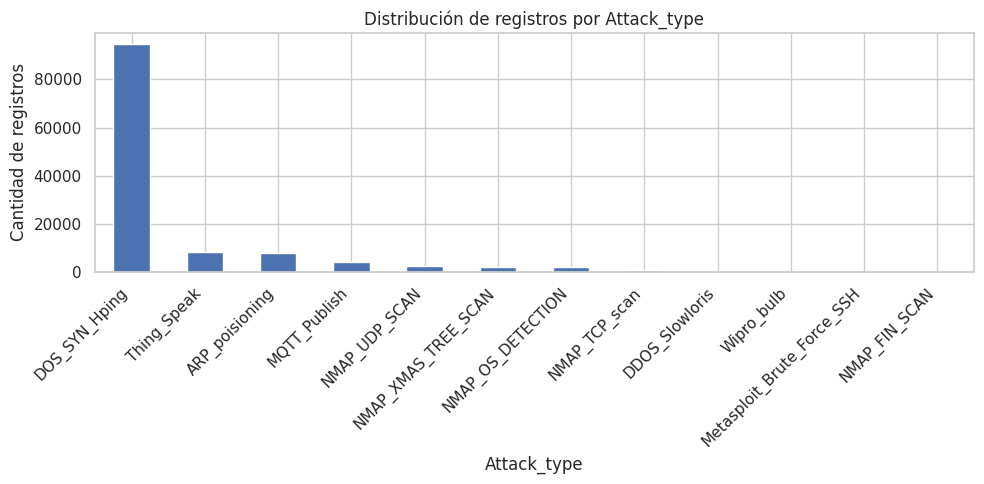

In [ ]:
conteo_attack_type = df_trafico[target].value_counts()

conteo_attack_type

#generamos un gráfico de barras para visualizar la distribución de registros por tipo de ataque
plt.figure(figsize=(10, 5))
conteo_attack_type.plot(kind="bar")
plt.title("Distribución de registros por Attack_type")
plt.xlabel("Attack_type")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

En el gráfico observamos que el dataset está fuertemente desbalanceado. La clase **DOS_SYN_Hping** concentra la mayor cantidad de registros. En comparación, categorías como **Thing_Speak**, **ARP_poisioning**, **MQTT_Publish**, **NMAP_UDP_SCAN**, **NMAP_XMAS_TREE_SCAN**, **NMAP_OS_DETECTION**, **NMAP_TCP_scan**, **DDOS_Slowloris**, **Wipro_bulb**, **Metasploit_Brute_Force_SSH** y **NMAP_FIN_SCAN** tienen una cantidad de registros mucho menor.

Esto debe tenerse en cuenta durante el análisis, porque las estadísticas generales pueden estar dominadas por el comportamiento de la clase **DOS_SYN_Hping**. Por ello, en las siguientes secciones se comparan las variables de tráfico y volumen por tipo de ataque, con el fin de identificar diferencias específicas entre las categorías y no depender únicamente de los promedios generales.

# 4. Histogramas de las variables

En esta sección se grafican histogramas para observar la distribución de las variables de tráfico y volumen.

Debido a que varias variables presentan valores extremos y escalas muy amplias, se aplicó una transformación logarítmica usando log(1 + x). Esta transformación permite visualizar mejor la concentración de los datos y reducir el efecto visual de los valores muy altos.

In [23]:
def graficar_histograma_log(columna):
    plt.figure(figsize=(8, 4))
    sns.histplot(np.log1p(df_trafico[columna]), bins=50, kde=True)
    plt.title(f"Histograma logarítmico de {columna}")
    plt.xlabel(f"log(1 + {columna})")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

## 4.1 Histograma de flow_duration

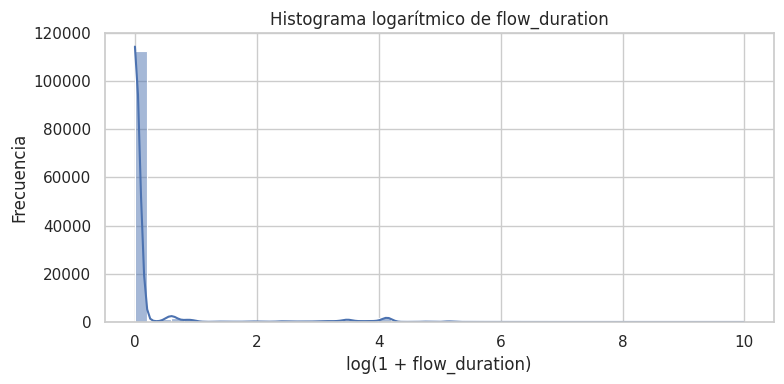

In [24]:
graficar_histograma_log("flow_duration")

### **Observaciones:**

La variable **flow_duration** muestra una alta concentración de registros en valores muy bajos, incluso después de aplicar la transformación logarítmica. Esto indica que la mayoría de los flujos de red tienen una duración muy corta. Sin embargo, también se observan algunos valores alejados hacia la derecha, lo que sugiere la existencia de flujos con duraciones mucho más largas que el comportamiento general.

Esto coincide con las estadísticas descriptivas, donde la mediana era muy baja, pero el valor máximo era extremadamente alto.

## 4.2 Histograma de fwd_pkts_tot

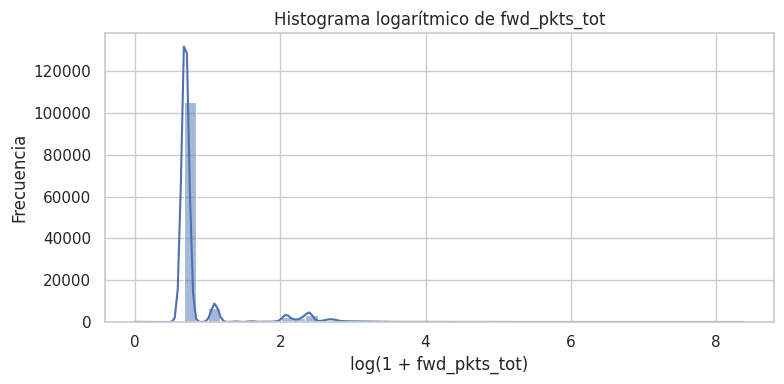

In [25]:
graficar_histograma_log("fwd_pkts_tot")

### **Observaciones:**

La variable fwd_pkts_tot presenta una fuerte concentración en valores bajos, especialmente alrededor de registros con pocos paquetes forward. Esto indica que la mayoría de los flujos tienen una cantidad reducida de paquetes enviados desde el origen hacia el destino.

También se observan pequeños grupos de registros con valores más altos, lo cual puede representar comunicaciones más intensas o comportamientos específicos asociados a ciertos tipos de ataque.

## 4.3 Histograma de bwd_pkts_tot

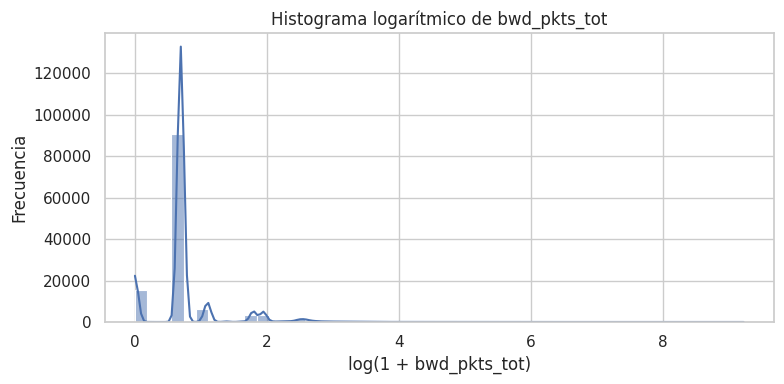

In [26]:
graficar_histograma_log("bwd_pkts_tot")

### **Observaciones:**

La distribución de bwd_pkts_tot también se concentra principalmente en valores bajos. Esto significa que la mayoría de los flujos reciben pocos paquetes en dirección backward. Sin embargo, existen valores más altos que pueden indicar respuestas más grandes desde el destino hacia el origen o comportamientos atípicos en algunos flujos.

Al igual que con fwd_pkts_tot, esta variable presenta una distribución sesgada, característica común en datos de tráfico de red.

## 4.4 Histograma de fwd_pkts_per_sec

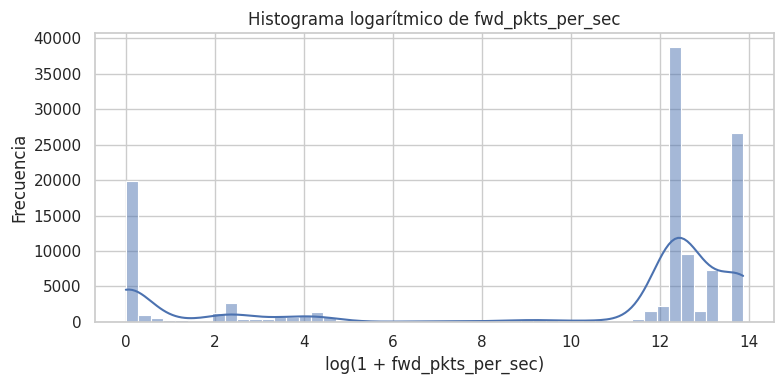

In [27]:
graficar_histograma_log("fwd_pkts_per_sec")

### **Observaciones:**

En fwd_pkts_per_sec se observa una distribución más dispersa. Hay un grupo de registros con valores muy bajos o cercanos a cero, pero también una concentración importante en valores logarítmicos altos. Esto sugiere que muchos flujos presentan tasas elevadas de paquetes forward por segundo.

Esta variable puede ser útil para detectar anomalías, ya que ciertos ataques pueden generar grandes cantidades de paquetes en intervalos cortos de tiempo.

## 4.5 Histograma de bwd_pkts_per_sec

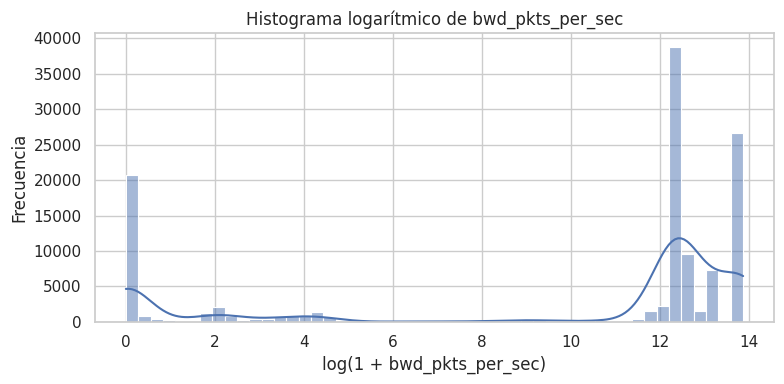

In [28]:
graficar_histograma_log("bwd_pkts_per_sec")

### **Observaciones:**

La variable bwd_pkts_per_sec presenta un comportamiento similar a fwd_pkts_per_sec, con una combinación de valores bajos y una concentración notable en valores altos. Esto indica que algunos flujos reciben paquetes en dirección backward a una tasa elevada.

Este comportamiento puede estar relacionado con respuestas rápidas del sistema, tráfico automatizado o patrones generados por determinados ataques.

## 4.6 Histograma de flow_pkts_per_sec

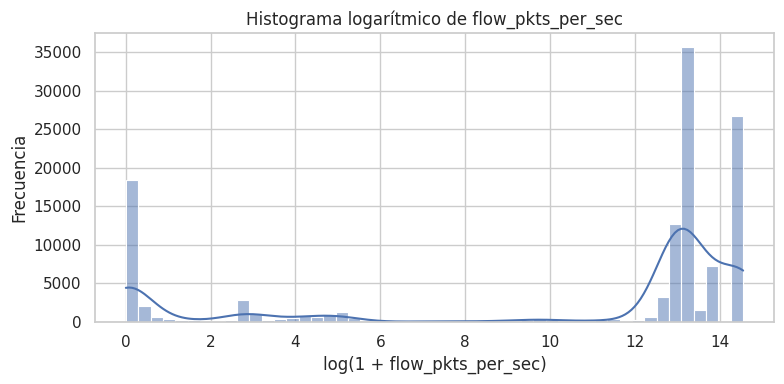

In [29]:
graficar_histograma_log("flow_pkts_per_sec")

### **Observaciones:**

La variable flow_pkts_per_sec representa la tasa total de paquetes por segundo dentro del flujo. Su distribución muestra registros con tasas muy bajas y también una concentración fuerte en valores altos. Esto indica que existen flujos con una actividad muy intensa en términos de paquetes transmitidos por segundo.

Esto es relevante para la detección de anomalías, ya que ataques como denegación de servicio pueden generar altos volúmenes de paquetes en poco tiempo.

## 4.7 Histograma de down_up_ratio

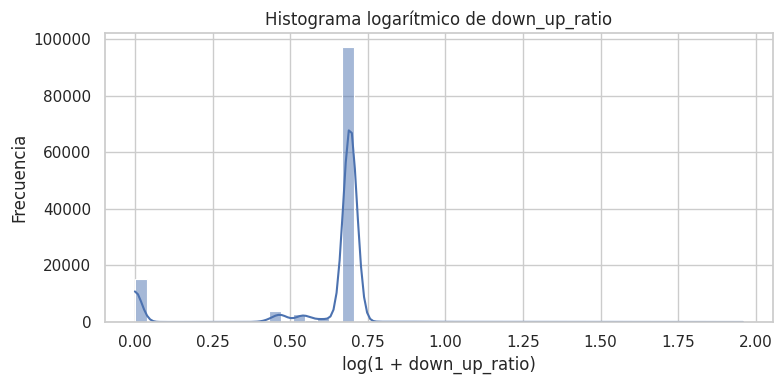

In [30]:
graficar_histograma_log("down_up_ratio")

### **Observaciones:**

La variable down_up_ratio presenta una concentración muy marcada alrededor de un valor específico, lo que indica que gran parte de los flujos mantienen una relación similar entre tráfico de bajada y subida. También se observan algunos registros con valores cercanos a cero y otros con relaciones más altas.

Esto puede ayudar a identificar comportamientos donde el tráfico está desbalanceado en una dirección, lo cual podría ser relevante para detectar ciertos tipos de ataques o comunicaciones anómalas.

## 4.8 Histograma de payload_bytes_per_second

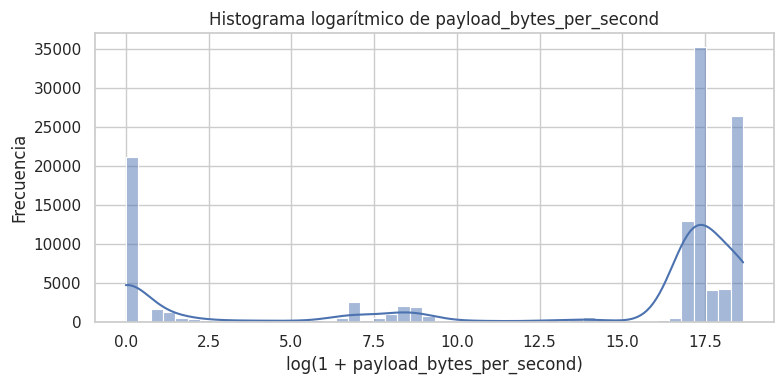

In [31]:
graficar_histograma_log("payload_bytes_per_second")

### **Observaciones:**

La variable payload_bytes_per_second muestra una distribución con registros de muy bajo volumen y una concentración importante en valores altos. Esto indica que algunos flujos transmiten poca o ninguna carga útil por segundo, mientras que otros presentan un volumen de payload considerable.

# 5. Boxplots generales para detectar outliers
En esta sección se utilizan boxplots para visualizar la dispersión de las variables de tráfico y volumen, así como la presencia de posibles valores atípicos. Permiten observar la mediana, el rango intercuartílico y los puntos que se alejan del comportamiento central de cada variable.

Al igual que en los histogramas, se aplica una transformación logarítmica log(1 + x) para facilitar la visualización, ya que varias variables tienen escalas muy amplias y valores extremos.

In [33]:
def graficar_boxplot_log(columna):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=np.log1p(df_trafico[columna]))
    plt.title(f"Boxplot logarítmico de {columna}")
    plt.xlabel(f"log(1 + {columna})")
    plt.tight_layout()
    plt.show()

## 5.1 Boxplot de flow_duration

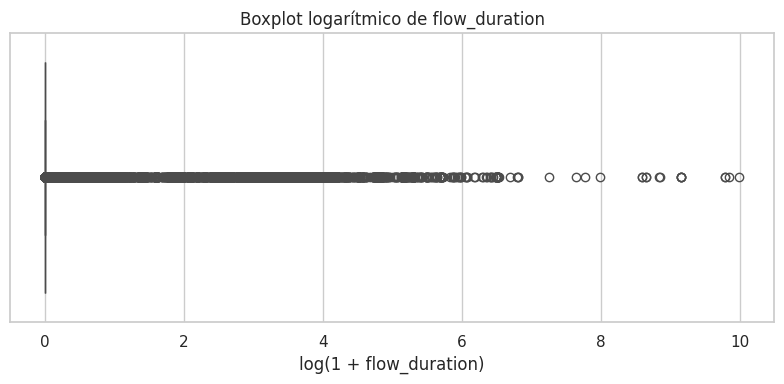

In [34]:
graficar_boxplot_log("flow_duration")

### **Observaciones:**

El boxplot de flow_duration muestra una gran concentración de valores cerca de cero y una cantidad importante de puntos alejados hacia la derecha. Esto indica que la mayoría de los flujos tienen una duración muy corta, pero existen algunos flujos con duraciones mucho mayores.

Estos valores extremos pueden corresponder a conexiones prolongadas, tráfico persistente o comportamientos anómalos asociados a ciertos tipos de ataque.

## 5.2 Boxplot de fwd_pkts_tot

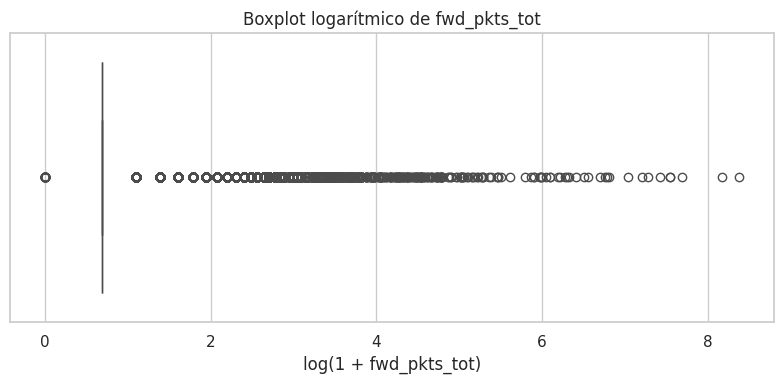

In [35]:
graficar_boxplot_log("fwd_pkts_tot")

### **Observaciones:**

En fwd_pkts_tot se observa que la mayoría de los registros se concentran en valores bajos, principalmente alrededor de un paquete forward. Sin embargo, aparecen múltiples puntos alejados hacia la derecha, lo que indica flujos con cantidades de paquetes forward mucho mayores al comportamiento típico.

Esto puede reflejar comunicaciones más intensas desde el origen hacia el destino o actividades sospechosas que generan muchos paquetes en una dirección.

## 5.3 Boxplot de bwd_pkts_tot

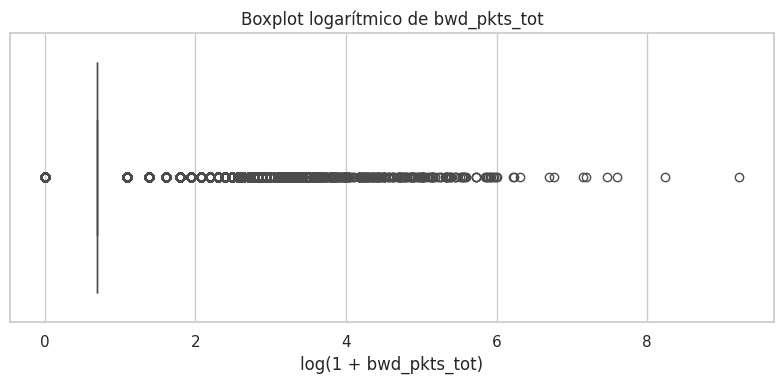

In [36]:
graficar_boxplot_log("bwd_pkts_tot")

### **Observaciones:**

La variable bwd_pkts_tot presenta un comportamiento similar a fwd_pkts_tot, pero con una presencia aún más marcada de valores atípicos. Esto indica que muchos registros tienen pocos paquetes backward, mientras que algunos flujos presentan una cantidad mucho mayor de paquetes de respuesta.

Este comportamiento puede estar relacionado con respuestas anómalas del destino, tráfico automatizado o comunicaciones asociadas a ataques específicos.

## 5.4 Boxplot de fwd_pkts_per_sec

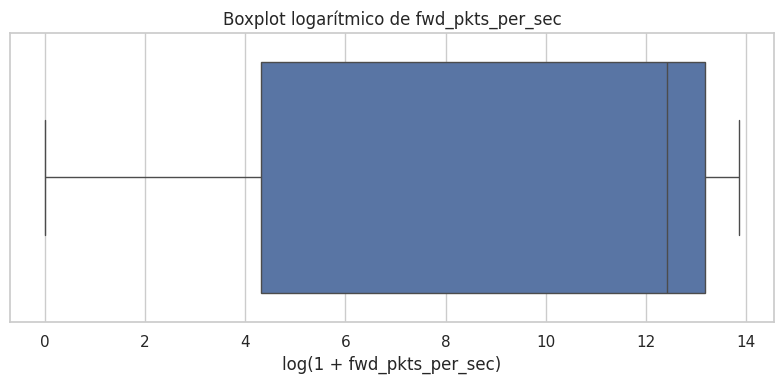

In [37]:
graficar_boxplot_log("fwd_pkts_per_sec")

### **Observaciones:**

El boxplot de fwd_pkts_per_sec muestra una dispersión amplia, pero no presenta puntos atípicos visibles bajo el criterio del boxplot. Esto se debe a que el rango intercuartílico de esta variable es bastante grande, por lo que los valores altos aún se encuentran dentro de los límites esperados según el método IQR.

Esta variable muestra alta variabilidad en la tasa de paquetes enviados por segundo, lo cual puede ser útil para diferenciar tipos de tráfico.

## 5.5 Boxplot de bwd_pkts_per_sec

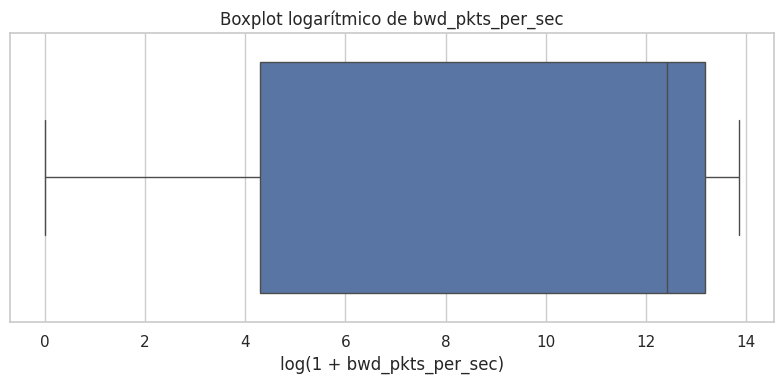

In [38]:
graficar_boxplot_log("bwd_pkts_per_sec")

### **Observaciones:**

La variable bwd_pkts_per_sec también presenta una distribución amplia, similar a fwd_pkts_per_sec. Aunque existen valores bajos y altos, el boxplot no marca outliers bajo el método visual, debido a que la dispersión general de la variable es elevada.

Esto indica que la tasa de paquetes recibidos por segundo varía considerablemente entre los registros del dataset.

## 5.6 Boxplot de flow_pkts_per_sec

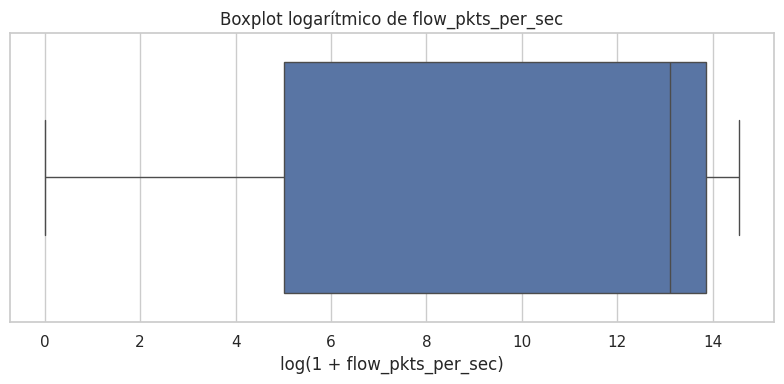

In [39]:
graficar_boxplot_log("flow_pkts_per_sec")

### **Observaciones:**

En flow_pkts_per_sec se observa una dispersión amplia en la tasa total de paquetes por segundo. No se evidencian outliers marcados bajo el boxplot, lo que sugiere que, aunque la variable tiene valores altos, estos hacen parte del rango esperado según la distribución general.

Esta variable sigue siendo relevante porque representa la intensidad total del flujo de red.

## 5.7 Boxplot de down_up_ratio

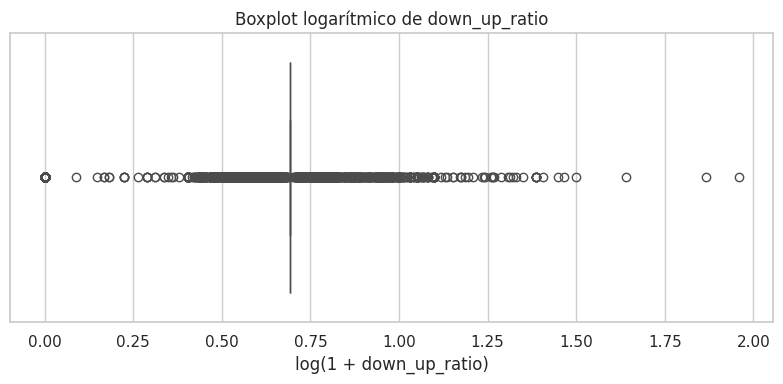

In [40]:
graficar_boxplot_log("down_up_ratio")

### **Observaciones:**

El boxplot de down_up_ratio muestra que la mayoría de los registros se concentran alrededor de una relación estable entre tráfico de bajada y subida. Sin embargo, se observan varios puntos alejados tanto hacia valores bajos como hacia valores altos.

Esto indica que algunos flujos presentan un desbalance significativo entre tráfico entrante y saliente, lo cual puede ser relevante para detectar patrones de comunicación anómalos.

## 5.8 Boxplot de payload_bytes_per_second

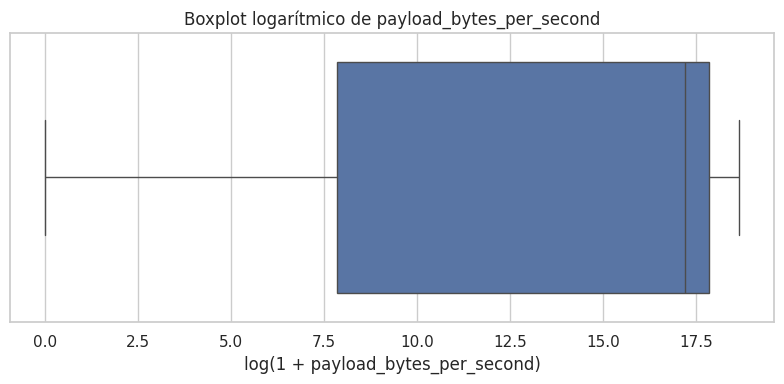

In [41]:
graficar_boxplot_log("payload_bytes_per_second")

### **Observaciones:**

La variable payload_bytes_per_second presenta una distribución amplia, con valores desde cero hasta niveles altos de bytes transmitidos por segundo. Aunque visualmente existe una gran dispersión, el método IQR no identifica outliers para esta variable debido a que el rango intercuartílico es amplio.

Esto indica que el volumen de payload por segundo varía mucho entre los registros, posiblemente por diferencias entre tráfico normal, comunicaciones IoT y ataques.

## 5.9 Detección de outliers mediante método IQR

Además de los boxplots, se aplicó el método del rango intercuartílico, conocido como IQR, para cuantificar los valores atípicos en cada variable. Este método calcula los límites inferior y superior a partir del primer cuartil, tercer cuartil y rango intercuartílico. De la forma:

> IQR = Q3 - Q1
>
>Límite inferior = Q1 - 1.5 * IQR
>
>Límite superior = Q3 + 1.5 * IQR

Tengase presente que en este tipo de datos, los outliers no necesariamente representan errores; pueden corresponder también a comportamientos anómalos, ataques o flujos con actividad inusualmente alta.

In [ ]:
# calculamos cuántos outliers tiene cada variable
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

    return {
        "variable": columna,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": len(outliers),
        "porcentaje_outliers": len(outliers) / len(data) * 100
    }

outliers_resumen = pd.DataFrame([
    detectar_outliers_iqr(df_trafico, col) for col in variables_trafico
])

outliers_resumen

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,porcentaje_outliers
0,flow_duration,0.000001,5.000000e-06,4.000000e-06,-5.000000e-06,1.100000e-05,19171,15.571367
1,fwd_pkts_tot,1.000000,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,17662,14.345704
2,bwd_pkts_tot,1.000000,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,32364,26.287190
3,fwd_pkts_per_sec,74.543538,5.242880e+05,5.242135e+05,-7.862456e+05,1.310608e+06,0,0.000000
4,bwd_pkts_per_sec,72.889275,5.242880e+05,5.242151e+05,-7.862498e+05,1.310611e+06,0,0.000000
5,flow_pkts_per_sec,149.087077,1.048576e+06,1.048427e+06,-1.572491e+06,2.621216e+06,0,0.000000
6,down_up_ratio,1.000000,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,25796,20.952427
7,payload_bytes_per_second,2580.981105,5.592405e+07,5.592147e+07,-8.387963e+07,1.398063e+08,0,0.000000


### **Observaciones:**

El método IQR identificó valores atípicos principalmente en **flow_duration**, **fwd_pkts_tot**, **bwd_pkts_tot** y **down_up_ratio**.

- La variable con mayor porcentaje de outliers fue **bwd_pkts_tot**, con aproximadamente 26.29% de registros atípicos. Esto indica que una proporción considerable de flujos presenta una cantidad de paquetes backward diferente al valor más común del dataset.

* En segundo lugar tenemos a **down_up_ratio**, con aproximadamente 20.95%, lo que sugiere que muchos flujos tienen una relación entre tráfico de bajada y subida distinta al valor dominante. Esto puede ser relevante para detectar comunicaciones desbalanceadas o patrones anómalos.

* En **flow_duration**, el porcentaje de outliers fue de aproximadamente 15.57%, lo cual refleja que existen flujos con duraciones superiores al comportamiento típico. Esto confirma lo observado en los histogramas y boxplots, donde la mayoría de los flujos tienen duraciones muy cortas, pero algunos se extienden mucho más.

* Para **fwd_pkts_tot** el porcentaje de outliers fue de aproximadamente 14.35%, lo que muestra que una parte de los flujos envía una cantidad de paquetes forward superior al patrón más común.

* Variables como **fwd_pkts_per_sec**, **bwd_pkts_per_sec**, **flow_pkts_per_sec** y **payload_bytes_per_second** no presentaron outliers bajo el método IQR ya que sus rangos intercuartílicos son muy amplios y, por tanto, los valores no quedan por fuera de los límites calculados.

* En **fwd_pkts_tot**, **bwd_pkts_tot** y **down_up_ratio**, el IQR resultó igual a cero porque los valores de Q1 y Q3 son iguales. Esto significa que al menos la mitad central de los datos tiene exactamente el mismo valor. En esos casos, cualquier valor diferente a ese valor dominante puede ser marcado como outlier.

# 6. Comparación de variables frente a Attack_type

En esta sección se comparan las variables de tráfico y volumen frente a la variable Attack_type. El objetivo es identificar si existen diferencias relevantes entre los distintos tipos de tráfico o ataques registrados en el dataset.

Para cada variable se calculan estadísticas agrupadas por tipo de ataque: cantidad de registros, media, mediana, desviación estándar, valor mínimo y valor máximo. La tabla se ordena de acuerdo con la mediana, ya que esta medida es más robusta frente a valores extremos que la media.

In [64]:
#función para generar la tabla de resumen por variable
def resumen_por_attack_type(columna):
    return (
        df_trafico.groupby(target)[columna]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_values("median", ascending=False)
    )

## 6.1 Comparación de flow_duration por Attack_type

In [56]:
resumen_por_attack_type("flow_duration")

,count,mean,median,std,min,max
Attack_type,,,,,,
MQTT_Publish,4146,43.397013,44.067645,24.341563,0.000000,353.112391
DDOS_Slowloris,534,14.699148,20.088963,14.124797,0.000000,30.870463
Metasploit_Brute_Force_SSH,37,3.006557,2.030317,5.210286,0.000000,29.289262
Wipro_bulb,253,586.845727,0.803326,2738.891638,0.000000,21728.335580
Thing_Speak,8108,0.934471,0.114787,5.251602,0.000000,184.414081
ARP_poisioning,7750,15.893538,0.000637,108.261070,0.000000,5341.392332
NMAP_XMAS_TREE_SCAN,2010,0.001171,0.000007,0.050426,0.000000,2.260214
NMAP_OS_DETECTION,2000,0.000008,0.000006,0.000007,0.000001,0.000048
NMAP_TCP_scan,1002,0.000019,0.000004,0.000269,0.000001,0.005989


### **Observaciones:**

La variable flow_duration muestra diferencias importantes entre los tipos de ataque. Los valores más altos de mediana aparecen en MQTT_Publish, seguido por DDOS_Slowloris y Metasploit_Brute_Force_SSH. Esto indica que estos tipos de tráfico tienden a generar flujos de mayor duración.

En contraste, ataques como DOS_SYN_Hping, NMAP_TCP_scan, NMAP_OS_DETECTION y otros escaneos NMAP presentan medianas extremadamente bajas o cercanas a cero, lo que sugiere flujos muy cortos. Esto puede asociarse con tráfico rápido, repetitivo o exploratorio.

En Wipro_bulb, se tiene una media muy alta, pero una mediana baja. Esto indica la presencia de algunos flujos extremadamente largos que elevan el promedio, aunque la mayoría de registros no tienen duraciones tan altas.

## 6.2 Comparación de fwd_pkts_tot por Attack_type

In [57]:
resumen_por_attack_type("fwd_pkts_tot")

,count,mean,median,std,min,max
Attack_type,,,,,,
Metasploit_Brute_Force_SSH,37,12.216216,14.0,6.320756,1,33
MQTT_Publish,4146,10.171973,10.0,25.851223,1,1661
Wipro_bulb,253,80.529644,10.0,407.144582,0,4345
DDOS_Slowloris,534,6.041199,6.0,1.642022,1,11
Thing_Speak,8108,5.392452,2.0,5.099881,0,130
ARP_poisioning,7750,8.296903,2.0,40.537051,0,2166
DOS_SYN_Hping,94659,1.000000,1.0,0.000000,1,1
NMAP_FIN_SCAN,28,1.214286,1.0,0.956736,1,6
NMAP_TCP_scan,1002,1.009980,1.0,0.140998,1,3


### **Observaciones:**

En fwd_pkts_tot, los valores más altos de mediana se observan en Metasploit_Brute_Force_SSH, MQTT_Publish y Wipro_bulb. Esto indica que estos tipos de tráfico tienden a enviar más paquetes en dirección forward.

Por otro lado, clases como DOS_SYN_Hping, NMAP_OS_DETECTION, NMAP_TCP_scan, NMAP_XMAS_TREE_SCAN, NMAP_FIN_SCAN y NMAP_UDP_SCAN tienen medianas cercanas a 1. Esto sugiere que muchos de estos ataques generan flujos con muy pocos paquetes enviados desde el origen hacia el destino.

La diferencia entre la media y la mediana en algunas clases, como Wipro_bulb, ARP_poisioning y MQTT_Publish, indica que existen valores extremos con muchos paquetes forward.

## 6.3 Comparación de bwd_pkts_tot por Attack_type

In [58]:
resumen_por_attack_type("bwd_pkts_tot")

,count,mean,median,std,min,max
Attack_type,,,,,,
Metasploit_Brute_Force_SSH,37,10.648649,13.0,6.680054,0,35
Wipro_bulb,253,17.126482,11.0,45.537964,0,405
MQTT_Publish,4146,8.277858,6.0,156.994533,0,10112
DDOS_Slowloris,534,5.035581,4.0,4.102881,0,13
Thing_Speak,8108,4.451406,2.0,5.206692,0,177
ARP_poisioning,7750,8.678065,2.0,62.783433,0,3782
DOS_SYN_Hping,94659,0.897633,1.0,0.303133,0,1
NMAP_OS_DETECTION,2000,1.000000,1.0,0.000000,1,1
NMAP_XMAS_TREE_SCAN,2010,0.996517,1.0,0.120095,0,5


### **Observaciones:**

La variable bwd_pkts_tot representa la cantidad de paquetes en dirección backward. Los valores más altos de mediana aparecen en Metasploit_Brute_Force_SSH, Wipro_bulb, MQTT_Publish y DDOS_Slowloris.

Esto sugiere que estos tipos de tráfico reciben más paquetes de respuesta en comparación con otros ataques. En cambio, NMAP_UDP_SCAN y NMAP_FIN_SCAN tienen mediana igual a cero, lo que indica que en muchos registros no se recibe tráfico backward o respuesta desde el destino.

Este comportamiento es relevante porque algunos ataques de escaneo pueden generar solicitudes sin obtener respuesta, mientras que otros tipos de tráfico implican una comunicación más bidireccional.

## 6.4 Comparación de fwd_pkts_per_sec por Attack_type

In [59]:
resumen_por_attack_type("fwd_pkts_per_sec")

,count,mean,median,std,min,max
Attack_type,,,,,,
NMAP_TCP_scan,1002,416853.084160,262144.000000,300233.317541,500.912102,1.048576e+06
DOS_SYN_Hping,94659,444796.206532,246723.764700,368949.952246,0.000000,1.048576e+06
NMAP_OS_DETECTION,2000,211007.472748,167772.160000,198236.623498,20867.184080,1.048576e+06
NMAP_XMAS_TREE_SCAN,2010,174497.435564,144631.172400,166274.738247,0.000000,1.048576e+06
Thing_Speak,8108,41.412894,11.225677,178.877357,0.000000,1.092267e+04
Metasploit_Brute_Force_SSH,37,97.644354,7.004034,408.796230,0.000000,2.336660e+03
Wipro_bulb,253,104.663612,6.853977,1053.877794,0.000000,1.667715e+04
ARP_poisioning,7750,1788.029684,3.266934,7732.263620,0.000000,4.934475e+05
DDOS_Slowloris,534,3344.628463,0.262112,7455.206084,0.000000,5.509759e+04


### **Observaciones:**

En fwd_pkts_per_sec, los valores de mediana más altos corresponden a NMAP_TCP_scan, DOS_SYN_Hping, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN. Esto indica que estos ataques generan paquetes forward a una tasa muy alta.

Este resultado es coherente con el comportamiento esperado de ataques de escaneo o denegación de servicio, donde se envían muchos paquetes en intervalos cortos de tiempo.

En contraste, tipos como MQTT_Publish, DDOS_Slowloris, NMAP_FIN_SCAN y NMAP_UDP_SCAN presentan medianas mucho más bajas o incluso iguales a cero.

## 6.5 Comparación de bwd_pkts_per_sec por Attack_type

In [60]:
resumen_por_attack_type("bwd_pkts_per_sec")

,count,mean,median,std,min,max
Attack_type,,,,,,
NMAP_TCP_scan,1002,416822.471280,262144.000000,300275.142896,0.00000,1.048576e+06
DOS_SYN_Hping,94659,444796.206532,246723.764700,368949.952246,0.00000,1.048576e+06
NMAP_OS_DETECTION,2000,211007.472748,167772.160000,198236.623498,20867.18408,1.048576e+06
NMAP_XMAS_TREE_SCAN,2010,174497.435124,144631.172400,166274.738709,0.00000,1.048576e+06
Wipro_bulb,253,229.761010,9.967651,1558.857057,0.00000,1.298546e+04
Thing_Speak,8108,38.451637,9.405038,129.707761,0.00000,4.650004e+03
Metasploit_Brute_Force_SSH,37,97.128578,6.291871,408.923168,0.00000,2.336660e+03
ARP_poisioning,7750,1680.858865,2.976979,3769.269438,0.00000,9.118052e+04
DDOS_Slowloris,534,181.430430,0.326738,313.913407,0.00000,1.131659e+03


### **Observaciones:**

La variable bwd_pkts_per_sec presenta un patrón similar a fwd_pkts_per_sec. Las clases NMAP_TCP_scan, DOS_SYN_Hping, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN tienen las medianas más altas.

Esto indica que, además de enviar paquetes rápidamente, algunos de estos flujos también reciben respuestas en intervalos cortos. Sin embargo, en ataques como NMAP_UDP_SCAN y NMAP_FIN_SCAN, la mediana es cero, lo que sugiere poca o ninguna respuesta backward en gran parte de los registros.

Esta variable ayuda a diferenciar ataques con comunicación bidireccional rápida frente a ataques donde predominan solicitudes sin respuesta.

## 6.6 Comparación de flow_pkts_per_sec por Attack_type

In [61]:
resumen_por_attack_type("flow_pkts_per_sec")

,count,mean,median,std,min,max
Attack_type,,,,,,
NMAP_TCP_scan,1002,833675.555449,524288.000000,600508.105044,667.882803,2.097152e+06
DOS_SYN_Hping,94659,889592.413067,493447.529400,737899.904491,0.000000,2.097152e+06
NMAP_OS_DETECTION,2000,422014.945500,335544.320000,396473.246999,41734.368160,2.097152e+06
NMAP_XMAS_TREE_SCAN,2010,348994.870690,289262.344800,332549.476958,0.000000,2.097152e+06
Thing_Speak,8108,79.864532,20.302535,286.883611,0.000000,1.092267e+04
Wipro_bulb,253,334.424622,20.093968,1872.358015,0.000000,1.667715e+04
Metasploit_Brute_Force_SSH,37,194.772932,13.343112,817.719068,0.000000,4.673319e+03
ARP_poisioning,7750,3468.888548,6.465031,10101.976962,0.000000,4.934475e+05
DDOS_Slowloris,534,3526.058894,0.649753,7403.610514,0.000000,5.509759e+04


### **Observaciones:**

flow_pkts_per_sec resume la tasa total de paquetes por segundo dentro del flujo. Las medianas más altas aparecen nuevamente en NMAP_TCP_scan, DOS_SYN_Hping, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN.

Esto confirma que estos tipos de ataque se caracterizan por una alta frecuencia de paquetes por segundo. En especial, DOS_SYN_Hping y los ataques NMAP muestran patrones de tráfico intensivo y rápido.

Por otro lado, MQTT_Publish, DDOS_Slowloris, NMAP_FIN_SCAN y NMAP_UDP_SCAN presentan medianas bajas, lo que indica flujos menos intensivos en términos de paquetes por segundo.

## 6.7 Comparación de down_up_ratio por Attack_type

In [62]:
resumen_por_attack_type("down_up_ratio")

,count,mean,median,std,min,max
Attack_type,,,,,,
DOS_SYN_Hping,94659,0.897633,1.000000,0.303133,0.0,1.000000
Thing_Speak,8108,0.861943,1.000000,0.217854,0.0,3.333333
NMAP_OS_DETECTION,2000,1.000000,1.000000,0.000000,1.0,1.000000
NMAP_TCP_scan,1002,0.996008,1.000000,0.057568,0.0,1.000000
Wipro_bulb,253,0.821580,1.000000,0.432347,0.0,3.000000
NMAP_XMAS_TREE_SCAN,2010,0.993888,1.000000,0.077307,0.0,1.000000
ARP_poisioning,7750,0.657274,0.920000,0.499477,0.0,5.464286
Metasploit_Brute_Force_SSH,37,0.794688,0.866667,0.307856,0.0,1.060606
DDOS_Slowloris,534,0.829714,0.800000,0.541066,0.0,1.857143


### **Observaciones:**

La variable down_up_ratio permite observar la relación entre tráfico de bajada y subida. Varias clases como DOS_SYN_Hping, Thing_Speak, NMAP_OS_DETECTION, NMAP_TCP_scan, Wipro_bulb y NMAP_XMAS_TREE_SCAN presentan mediana igual a 1, lo que indica una relación equilibrada entre ambas direcciones.

En cambio, MQTT_Publish, DDOS_Slowloris, ARP_poisioning y Metasploit_Brute_Force_SSH tienen medianas inferiores a 1, lo que sugiere una diferencia entre el tráfico enviado y recibido.

Los casos NMAP_FIN_SCAN y NMAP_UDP_SCAN presentan mediana igual a cero, lo que puede indicar ausencia de tráfico de respuesta o una comunicación muy desbalanceada.

## 6.8 Comparación de payload_bytes_per_second por Attack_type

In [63]:
resumen_por_attack_type("payload_bytes_per_second")

,count,mean,median,std,min,max
Attack_type,,,,,,
DOS_SYN_Hping,94659,5.337554e+07,2.960685e+07,4.427399e+07,0.0,1.258291e+08
Thing_Speak,8108,4.907841e+03,3.763551e+03,2.429242e+04,0.0,9.242403e+05
Wipro_bulb,253,2.238629e+04,1.433639e+03,1.341652e+05,0.0,1.817810e+06
Metasploit_Brute_Force_SSH,37,1.389489e+04,1.394859e+03,5.517733e+04,0.0,3.084391e+05
ARP_poisioning,7750,2.229550e+05,1.018168e+03,4.785269e+05,0.0,4.348223e+06
DDOS_Slowloris,534,9.363590e+04,1.007158e+02,1.961443e+05,0.0,1.460086e+06
MQTT_Publish,4146,6.551782e+01,2.527796e+00,3.773219e+03,0.0,2.428395e+05
NMAP_FIN_SCAN,28,4.463262e+03,0.000000e+00,2.151783e+04,0.0,1.140259e+05
NMAP_TCP_scan,1002,7.794367e+01,0.000000e+00,1.744482e+03,0.0,4.018495e+04


### **Observaciones:**

En payload_bytes_per_second, la clase DOS_SYN_Hping presenta una mediana mucho más alta que el resto. Esto indica que este tipo de ataque concentra una gran cantidad de bytes de payload transmitidos por segundo.

Por otro lado, clases como NMAP_OS_DETECTION, NMAP_XMAS_TREE_SCAN, NMAP_TCP_scan, NMAP_FIN_SCAN y NMAP_UDP_SCAN tienen mediana igual a cero. Esto sugiere que muchos registros de estos ataques no transportan carga útil significativa, lo cual puede ser característico de ciertos escaneos de red.

Clases como Thing_Speak, Wipro_bulb, Metasploit_Brute_Force_SSH, ARP_poisioning y DDOS_Slowloris presentan valores intermedios, aunque con diferencias importantes entre media y mediana, lo que evidencia presencia de valores extremos.

## Conclusiones

- Los ataques NMAP y DOS_SYN_Hping se caracterizan principalmente por tasas altas de paquetes por segundo.

- Los ataques MQTT_Publish, DDOS_Slowloris y Metasploit_Brute_Force_SSH presentan flujos de mayor duración o mayor cantidad de paquetes por flujo.

También se observan diferencias importantes en down_up_ratio y payload_bytes_per_second, lo que indica que algunos ataques generan comunicaciones más equilibradas, mientras que otros presentan tráfico desbalanceado o poca carga útil. Estas diferencias sugieren que las variables seleccionadas son útiles para caracterizar comportamientos normales y anómalos en tráfico IoT.

# 7. Boxplots por Attack_type

En esta sección se generan boxplots para comparar visualmente la distribución de cada variable de tráfico y volumen frente a la variable Attack_type.

Se vuelve a aplicar una transformación logarítmica usando log(1 + x) para visualizar mejor las diferencias entre clases y reducir el impacto visual de valores muy altos.

In [54]:
df_log = df_trafico.copy()

for col in variables_trafico:
    df_log[col] = np.log1p(df_log[col])

def graficar_boxplot_por_attack_type(columna):
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_log, x=target, y=col)
    plt.title(f"log(1 + {col}) por Attack_type")
    plt.xlabel("Attack_type")
    plt.ylabel(f"log(1 + {col})")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 7.1 Boxplot de flow_duration por Attack_type

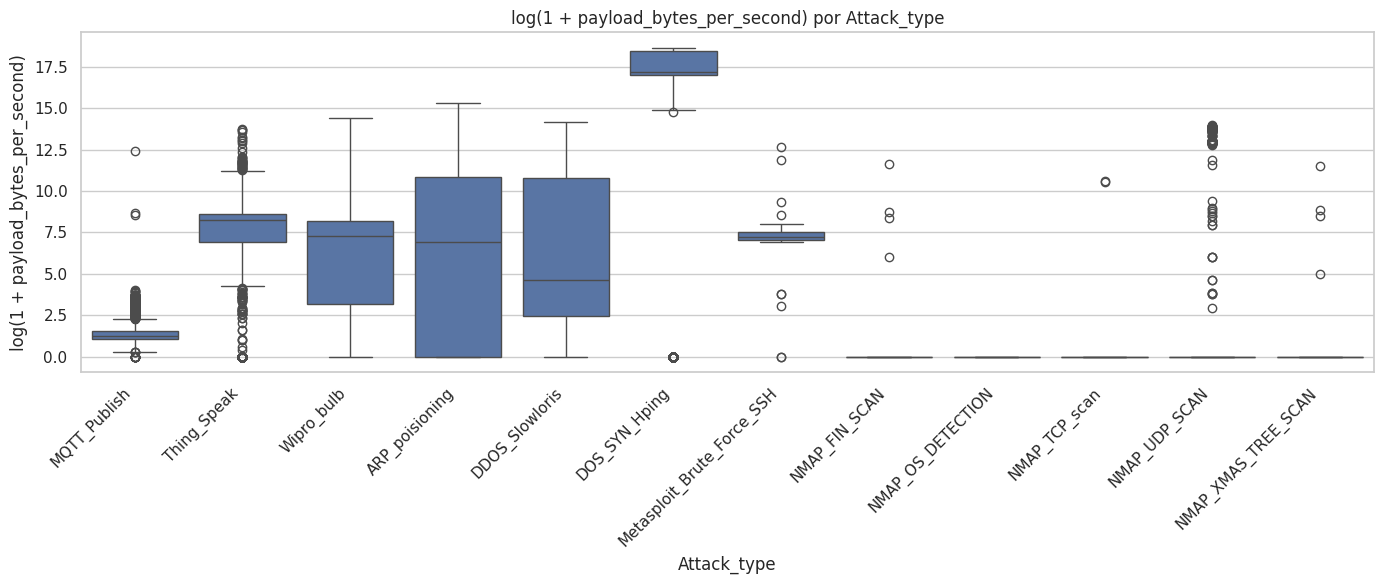

In [65]:
graficar_boxplot_por_attack_type("flow_duration")

### **Observaciones:**

El boxplot de flow_duration muestra diferencias claras entre los tipos de tráfico. MQTT_Publish presenta valores altos y relativamente concentrados, lo que indica flujos de mayor duración y comportamiento más estable. DDOS_Slowloris también muestra flujos con duraciones elevadas, aunque con una distribución amplia.

Por otro lado, ataques como DOS_SYN_Hping, NMAP_OS_DETECTION, NMAP_TCP_scan, NMAP_FIN_SCAN y NMAP_XMAS_TREE_SCAN presentan valores muy bajos, lo que indica flujos de duración extremadamente corta.

Wipro_bulb y ARP_poisioning muestran alta dispersión y presencia de valores extremos, lo que sugiere que dentro de estas clases existen comportamientos variados en la duración de los flujos.

## 7.2 Boxplot de fwd_pkts_tot por Attack_type

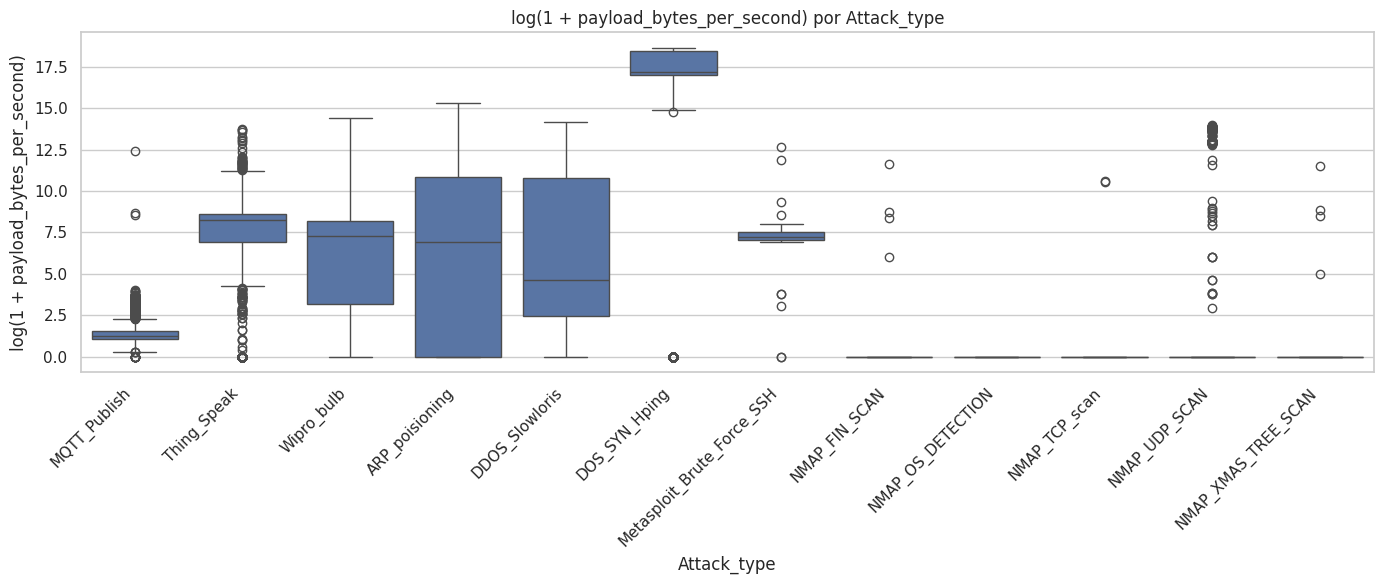

In [66]:
graficar_boxplot_por_attack_type("fwd_pkts_tot")

### **Observaciones:**

En fwd_pkts_tot, se observa que Metasploit_Brute_Force_SSH, MQTT_Publish, Wipro_bulb y DDOS_Slowloris presentan mayores cantidades de paquetes forward por flujo.

En cambio, DOS_SYN_Hping y varios ataques NMAP tienen valores muy bajos y concentrados, lo que indica que suelen generar pocos paquetes por flujo. Esto es coherente con ataques de escaneo o tráfico de corta duración.

Wipro_bulb y ARP_poisioning presentan varios valores extremos, lo que sugiere que algunos flujos pueden contener cantidades de paquetes mucho mayores al patrón central de su clase.

##7.3 Boxplot de bwd_pkts_tot por Attack_type

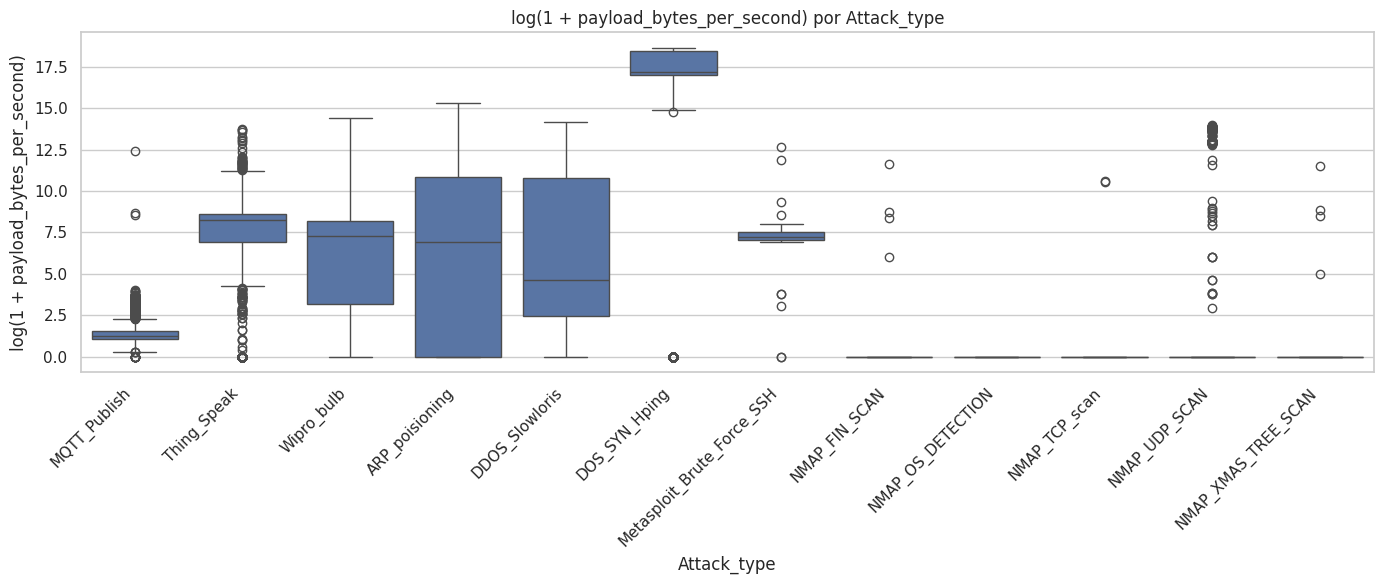

In [67]:
graficar_boxplot_por_attack_type("bwd_pkts_tot")

### **Observaciones:**

La variable bwd_pkts_tot muestra que Metasploit_Brute_Force_SSH, Wipro_bulb, MQTT_Publish y DDOS_Slowloris presentan mayor cantidad de paquetes backward, lo que indica una comunicación más bidireccional.

Por el contrario, NMAP_UDP_SCAN y NMAP_FIN_SCAN tienen valores muy bajos o cercanos a cero, lo cual puede indicar ausencia de respuesta desde el destino. Esto es común en ciertos escaneos, donde se envían solicitudes pero no siempre se recibe respuesta.

ARP_poisioning muestra alta dispersión y muchos valores extremos, lo que indica variabilidad en la cantidad de paquetes backward.



##7.4 Boxplot de fwd_pkts_per_sec por Attack_type

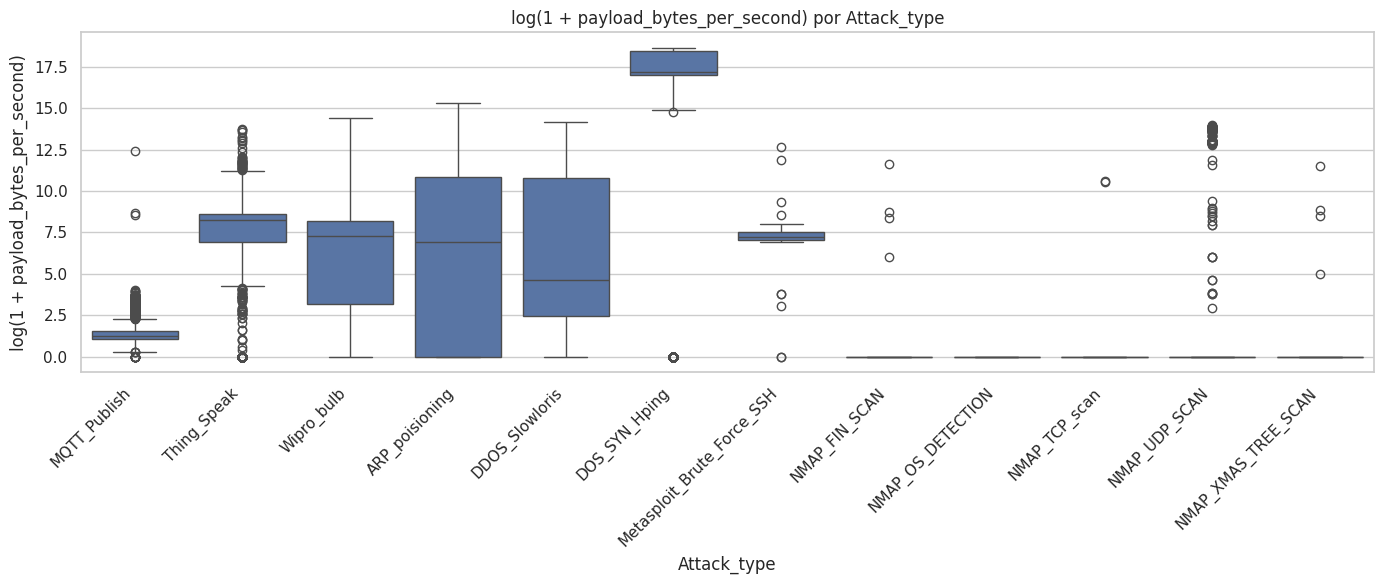

In [68]:
graficar_boxplot_por_attack_type("fwd_pkts_per_sec")

### **Observaciones:**

En fwd_pkts_per_sec se observan diferencias marcadas entre clases. DOS_SYN_Hping, NMAP_TCP_scan, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN presentan tasas altas de paquetes forward por segundo.

Este comportamiento es relevante porque estos ataques generan tráfico rápido y repetitivo, lo cual puede ser característico de escaneos o ataques de denegación de servicio.

En contraste, MQTT_Publish, DDOS_Slowloris, NMAP_FIN_SCAN y NMAP_UDP_SCAN presentan valores bajos en la mayoría de los registros.

##7.5 Boxplot de bwd_pkts_per_sec por Attack_type

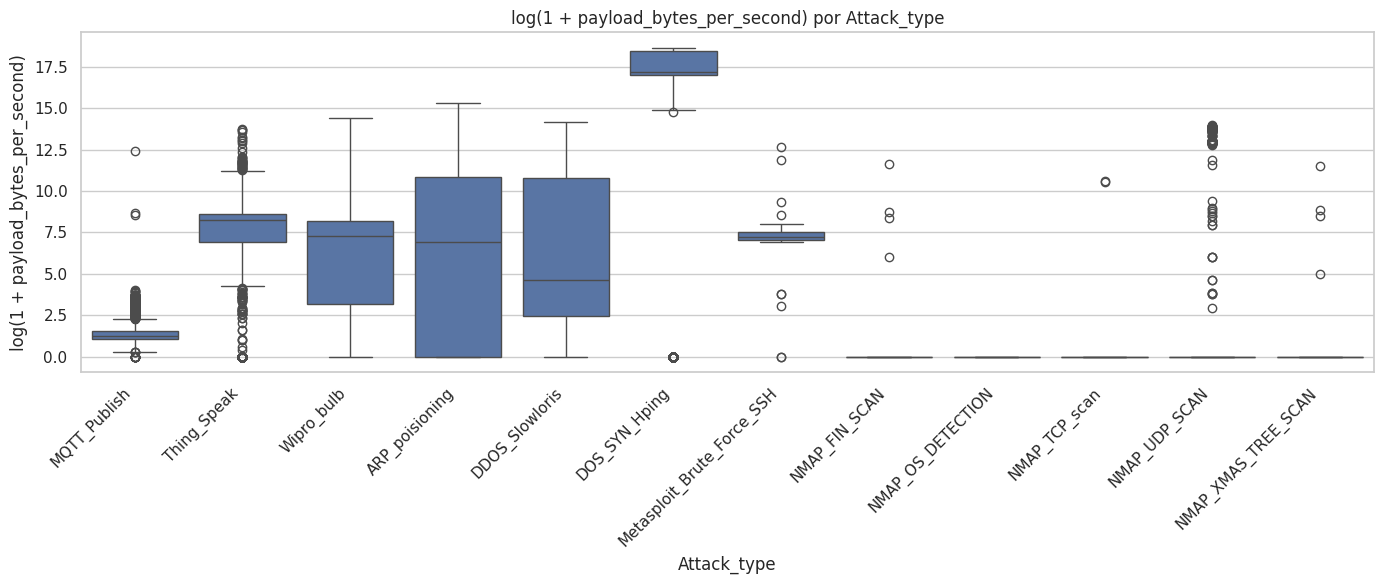

In [69]:
graficar_boxplot_por_attack_type("bwd_pkts_per_sec")

### **Observaciones:**

El comportamiento de bwd_pkts_per_sec es similar al de fwd_pkts_per_sec. Las clases DOS_SYN_Hping, NMAP_TCP_scan, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN presentan valores altos, lo cual indica respuestas o intercambios rápidos de paquetes.

En ataques como NMAP_UDP_SCAN y NMAP_FIN_SCAN, los valores se mantienen cercanos a cero, lo que sugiere poca actividad en dirección backward. Esto ayuda a diferenciar ataques con comunicación bidireccional rápida frente a ataques con pocas respuestas.

##7.6 Boxplot de flow_pkts_per_sec por Attack_type

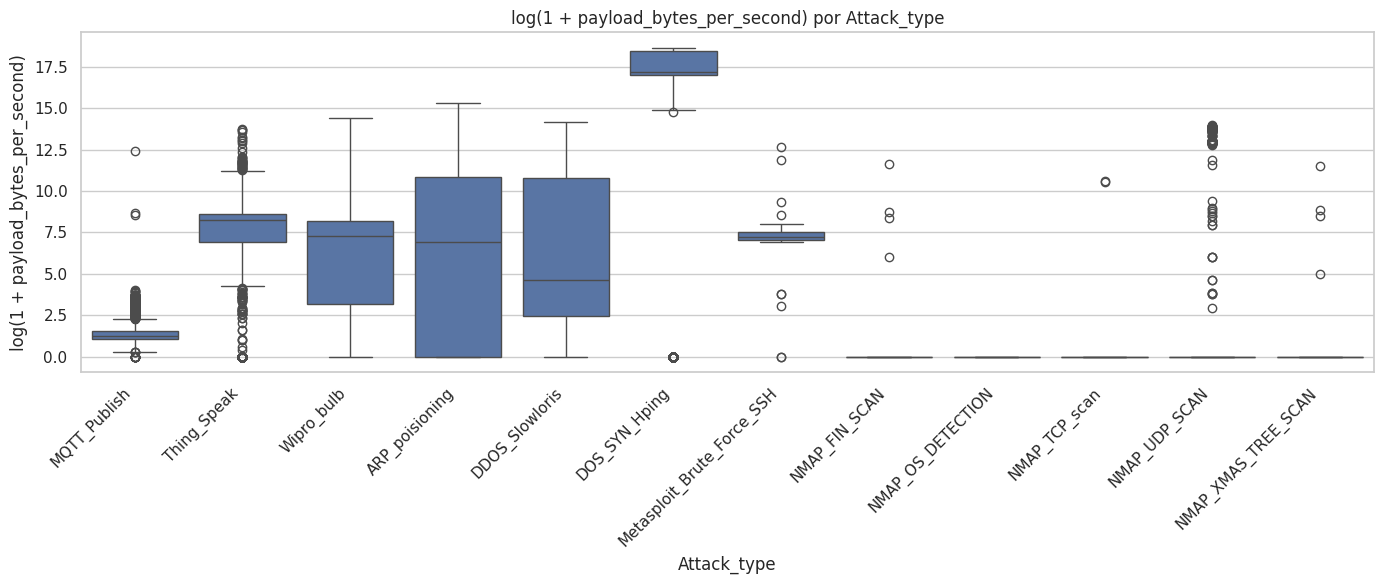

In [70]:
graficar_boxplot_por_attack_type("flow_pkts_per_sec")

### **Observaciones:**

La variable flow_pkts_per_sec confirma el patrón observado en las variables anteriores. DOS_SYN_Hping, NMAP_TCP_scan, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN presentan las tasas totales de paquetes por segundo más altas.

Esto indica que estos ataques se caracterizan por flujos muy rápidos e intensivos en cantidad de paquetes. En cambio, MQTT_Publish, DDOS_Slowloris, NMAP_FIN_SCAN y NMAP_UDP_SCAN presentan tasas más bajas en la mayoría de los registros.

##7.7 Boxplot de down_up_ratio por Attack_type

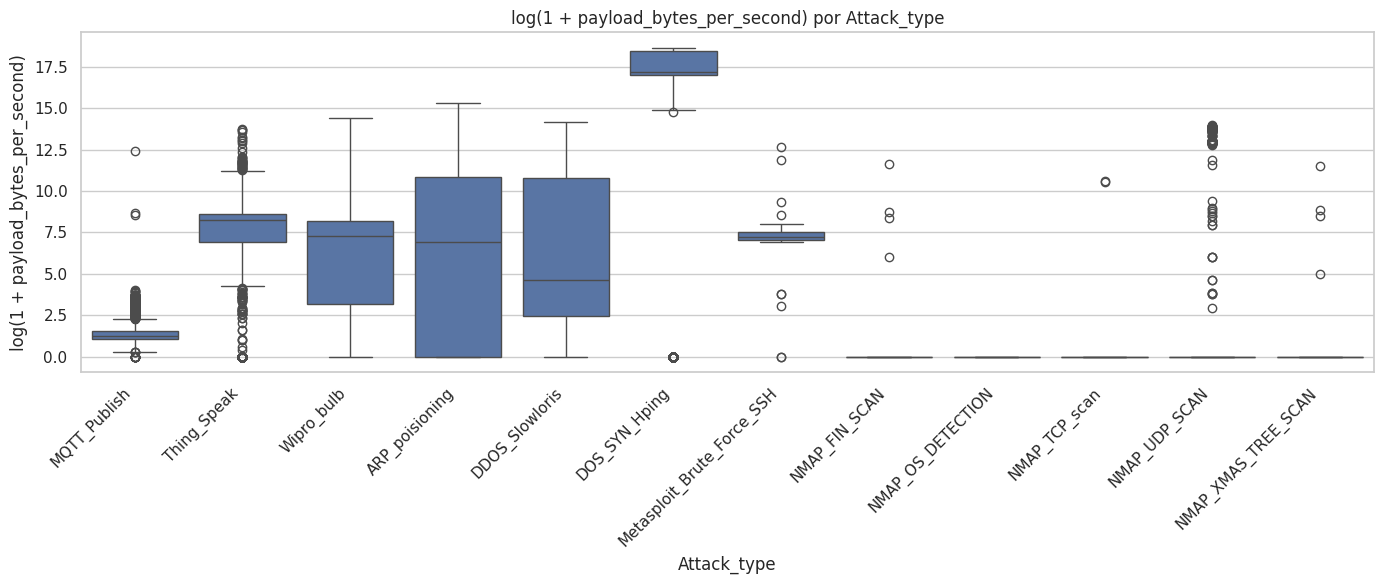

In [71]:
graficar_boxplot_por_attack_type("down_up_ratio")

### **Observaciones:**

La variable down_up_ratio permite observar el equilibrio entre tráfico de bajada y subida. Varias clases, como DOS_SYN_Hping, NMAP_OS_DETECTION y NMAP_XMAS_TREE_SCAN, presentan valores concentrados alrededor de una relación estable.

Por otro lado, MQTT_Publish, ARP_poisioning, DDOS_Slowloris y Thing_Speak muestran mayor variabilidad. Esto indica que en estas clases la relación entre tráfico entrante y saliente cambia más entre registros.

NMAP_UDP_SCAN y NMAP_FIN_SCAN aparecen con valores cercanos a cero, lo que puede indicar comunicaciones con muy poca respuesta o tráfico fuertemente desbalanceado.

##7.8 Boxplot de payload_bytes_per_second por Attack_type

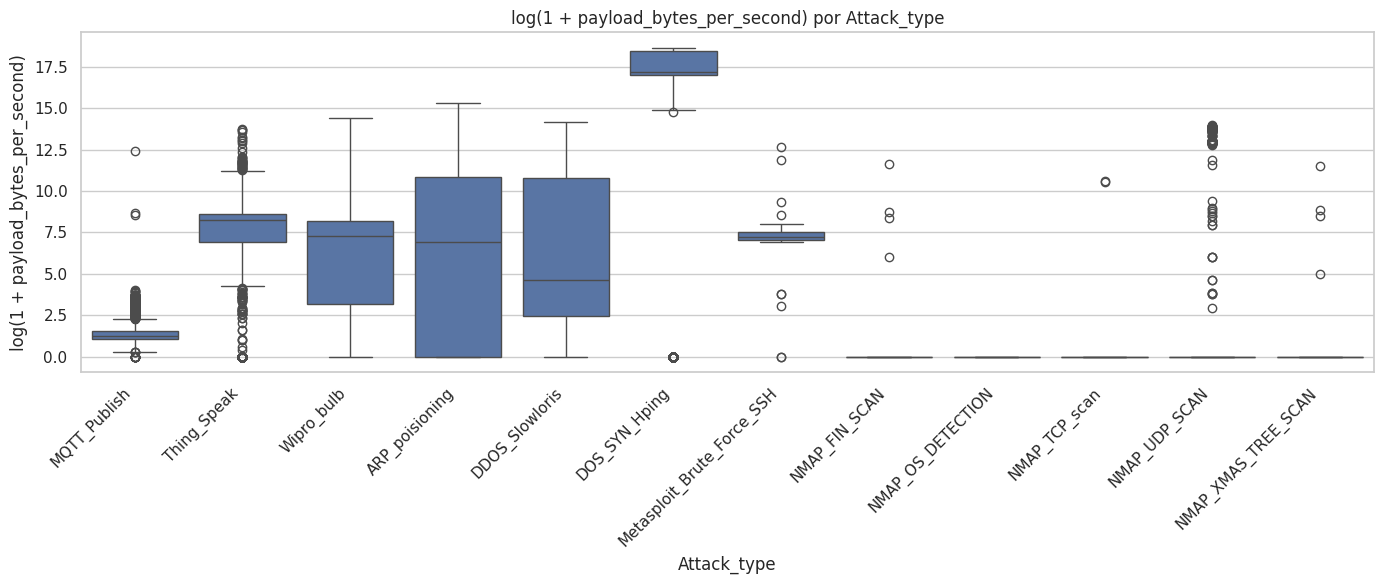

In [72]:
graficar_boxplot_por_attack_type("payload_bytes_per_second")

### **Observaciones:**

En payload_bytes_per_second, DOS_SYN_Hping presenta los valores más altos y concentrados, lo que indica un volumen elevado de payload por segundo. Esto lo diferencia claramente de muchas otras clases.

Thing_Speak, Wipro_bulb, ARP_poisioning, DDOS_Slowloris y Metasploit_Brute_Force_SSH muestran valores intermedios o variables, mientras que varios ataques NMAP presentan valores cercanos a cero. Esto sugiere que algunos escaneos generan poco o ningún payload significativo.

Esta variable puede ser útil para distinguir ataques de alto volumen frente a escaneos o comunicaciones con baja carga útil.

# 8. Hallazgos principales

A partir de las estadísticas, histogramas, boxplots, detección de outliers y comparación por Attack_type, se identificaron diferencias relevantes entre los tipos de tráfico y ataque:

- Las variables relacionadas con paquetes por segundo (**fwd_pkts_per_sec**, **bwd_pkts_per_sec** y **flow_pkts_per_sec**) permiten distinguir ataques como **DOS_SYN_Hping**, **NMAP_TCP_scan**, **NMAP_OS_DETECTION** y **NMAP_XMAS_TREE_SCAN**, los cuales presentan tasas elevadas de paquetes en intervalos cortos.

- Variables como **flow_duration**, **fwd_pkts_tot** y **bwd_pkts_tot** ayudan a diferenciar clases con comunicaciones más prolongadas o con mayor intercambio de paquetes, como **MQTT_Publish**, **DDOS_Slowloris**, **Wipro_bulb** y **Metasploit_Brute_Force_SSH**.

- La variable **down_up_ratio** muestra diferencias en el equilibrio entre tráfico de subida y bajada. Algunas clases presentan relaciones cercanas a 1, mientras que otras, como **NMAP_UDP_SCAN** y **NMAP_FIN_SCAN**, muestran valores cercanos a 0, lo que puede indicar poca o nula respuesta desde el destino.

- La variable **payload_bytes_per_second** permite identificar diferencias en el volumen de carga útil transmitida. **DOS_SYN_Hping** se destaca por presentar valores mucho más altos que el resto, mientras que varios ataques NMAP presentan valores bajos o nulos de payload.

En conclusión, las variables seleccionadas permiten caracterizar diferencias importantes entre tipos de tráfico y ataques. Por esta razón, pueden ser útiles para etapas posteriores de detección de anomalías en dispositivos IoT.